# Decision Trees

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


### CART Example using Sklearn: Use a new Dataset, complete preprocessing, use three data
### partitions: Training, Tuning and Testing, and build a model!

In [2]:
#Read in the data from the github repo, you should also have this saved locally...
winequality = pd.read_csv("https://raw.githubusercontent.com/UVADS/DS-3001/main/data/winequality-red-ddl.csv")

In [3]:
#Let's take a look...
print(winequality.info())
print(winequality.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1575 non-null   float64
 2   citric acid           1595 non-null   float64
 3   residual sugar        1586 non-null   float64
 4   chlorides             1587 non-null   float64
 5   free sulfur dioxide   1583 non-null   float64
 6   total sulfur dioxide  1574 non-null   float64
 7   density               1579 non-null   float64
 8   pH                    1597 non-null   float64
 9   sulphates             1591 non-null   float64
 10  alcohol               1589 non-null   float64
 11  quality               1581 non-null   float64
 12  text_rank             1581 non-null   object 
dtypes: float64(12), object(1)
memory usage: 162.5+ KB
None
   fixed acidity  volatile acidity  citric acid  residual sugar  chl

In [4]:
#This will be our target variable
print(winequality.text_rank.value_counts())

text_rank
ave            678
average-ish    630
good           193
poor-ish        53
excellent       17
poor            10
Name: count, dtype: int64


## Preprocessing

In [5]:
#drop quality column since it predicts text_rank perfectly
winequality= winequality.drop(columns='quality')

## Missing Data

In [6]:
#Let's see if we have any NA's
print(winequality.isna().sum()) #show location of NA's by variable

fixed acidity            0
volatile acidity        24
citric acid              4
residual sugar          13
chlorides               12
free sulfur dioxide     16
total sulfur dioxide    25
density                 20
pH                       2
sulphates                8
alcohol                 10
text_rank               18
dtype: int64


In [7]:
#Let's just drop them
winequality= winequality.dropna()

In [8]:
print(winequality.info()) #Lost some rows, but should be fine with this size dataset

<class 'pandas.core.frame.DataFrame'>
Index: 1482 entries, 0 to 1580
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1482 non-null   float64
 1   volatile acidity      1482 non-null   float64
 2   citric acid           1482 non-null   float64
 3   residual sugar        1482 non-null   float64
 4   chlorides             1482 non-null   float64
 5   free sulfur dioxide   1482 non-null   float64
 6   total sulfur dioxide  1482 non-null   float64
 7   density               1482 non-null   float64
 8   pH                    1482 non-null   float64
 9   sulphates             1482 non-null   float64
 10  alcohol               1482 non-null   float64
 11  text_rank             1482 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.5+ KB
None


## Collapsing the target

In [9]:
#Let's collapse text_rank now into only two classes
winequality.text_rank.value_counts() #What should we combine?

,count
text_rank,
ave,635
average-ish,583
good,186
poor-ish,51
excellent,17
poor,10


In [10]:
#Condense everything into either average or excellent
winequality["text_rank"]= winequality["text_rank"].replace(['good','average-ish','poor-ish','poor'], ['excellent','ave','ave','ave'])
print(winequality["text_rank"].value_counts()) #Great!

text_rank
ave          1279
excellent     203
Name: count, dtype: int64


In [11]:
#check the prevalence
print(203/(1279+203))

0.1369770580296896


In [12]:
#Before we move forward, we have one more preprocessing step
#We must encode text_rank to become a integer array variable as that is the only type sklearn decision trees can currently take
winequality[["text_rank"]] = OrdinalEncoder().fit_transform(winequality[["text_rank"]])
print(winequality["text_rank"].value_counts()) #nice

text_rank
0.0    1279
1.0     203
Name: count, dtype: int64


## Splitting the Data

In [13]:
#split independent and dependent variables
X= winequality.drop(columns='text_rank')
y= winequality.text_rank

In [14]:
#There is not a easy way to create 3 partitions using the train_test_split
#so we are going to use it twice. Mostly because we want to stratify on the variable we are working to predict. What does that mean?

#what should I stratify by??? Our Target!
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)


## Let's Build the Model

In [15]:
#Three steps in building a ML model
#Step 1: Cross validation process- the process by which the training data will be used to build the initial model must be set. As seen below:

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)
# number - number of folds
# repeats - number of times the CV is repeated, takes the average of these repeat rounds

# This essentially will split our training data into k groups. For each unique group it will hold out one as a test set
# and take the remaining groups as a training set. Then, it fits a model on the training set and evaluates it on the test set.
# Retains the evaluation score and discards the model, then summarizes the skill of the model using the sample of model evaluation scores we choose

In [16]:
#What score do we want our model to be built on? Let's use:
#AUC for the ROC curve - remember this measures how well our model distinguishes between classes
#Recall - this is sensitivity of our model, also known as the true positive rate (predicted pos when actually pos)
#Balanced accuracy - this is (sensitivity + specificity)/2
# In newer scikit-learn versions use get_scorer_names() instead of the deprecated SCORERS dict
from sklearn.metrics import get_scorer_names
print(get_scorer_names())


['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

In [17]:
#Define score, these are the keys we located above. This is what the models will be scored by
scoring = ['roc_auc','recall','balanced_accuracy']

In [65]:
#Step 2: Usually involves setting a hyper-parameter search. This is optional and the hyper-parameters vary by model.
#define parameters, we can use any number of the ones below but let's start with only max depth
#this will help us find a good balance between under fitting and over fitting in our model
#
# NOTE: When using a Pipeline, hyper-parameter names must be prefixed with the step name followed
# by '__' (double underscore).  Our classifier step is named 'classifier', so max_depth becomes
# 'classifier__max_depth'.

param={#"classifier__max_depth" : [6],
        #"classifier__splitter":["best","random"],
        #"classifier__min_samples_split":[5,10,15,20,25],
        "classifier__min_samples_leaf":[5,10,15,20,25],
        #"classifier__max_features":["auto","log2","sqrt",None],
        #"classifier__max_leaf_nodes":[10,20,30,40,50],
        #"classifier__min_impurity_decrease":[0.002],
        #"classifier__ccp_alpha" :[.001]
           }


In [66]:
#Step 3: Train the Model using a sklearn Pipeline
#
# A Pipeline chains together one or more steps.  Each step except the last must be a transformer
# (implements fit/transform); the final step can be an estimator (implements fit/predict).
# Benefits:
#   * Keeps preprocessing and modelling code together and reproducible
#   * Prevents data leakage: transformers are only fit on training folds inside cross-validation
#   * Makes the whole workflow deployable as a single object

# Build the pipeline – a single-step pipeline wrapping the classifier
pipe = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=1000))
])

#Set up search: pass the pipeline (not the bare classifier) to GridSearchCV
search = GridSearchCV(pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)


## Let's see how we did

In [67]:
#Retrieve the best estimator – this is the full Pipeline fitted with the best hyper-parameters
best = model.best_estimator_
print(best)

# To access the underlying DecisionTreeClassifier from the pipeline:
best_clf = best.named_steps['classifier']
print('\nBest max_depth:', best_clf.max_depth)


Pipeline(steps=[('classifier',
                 DecisionTreeClassifier(min_samples_leaf=20,
                                        random_state=1000))])

Best max_depth: None


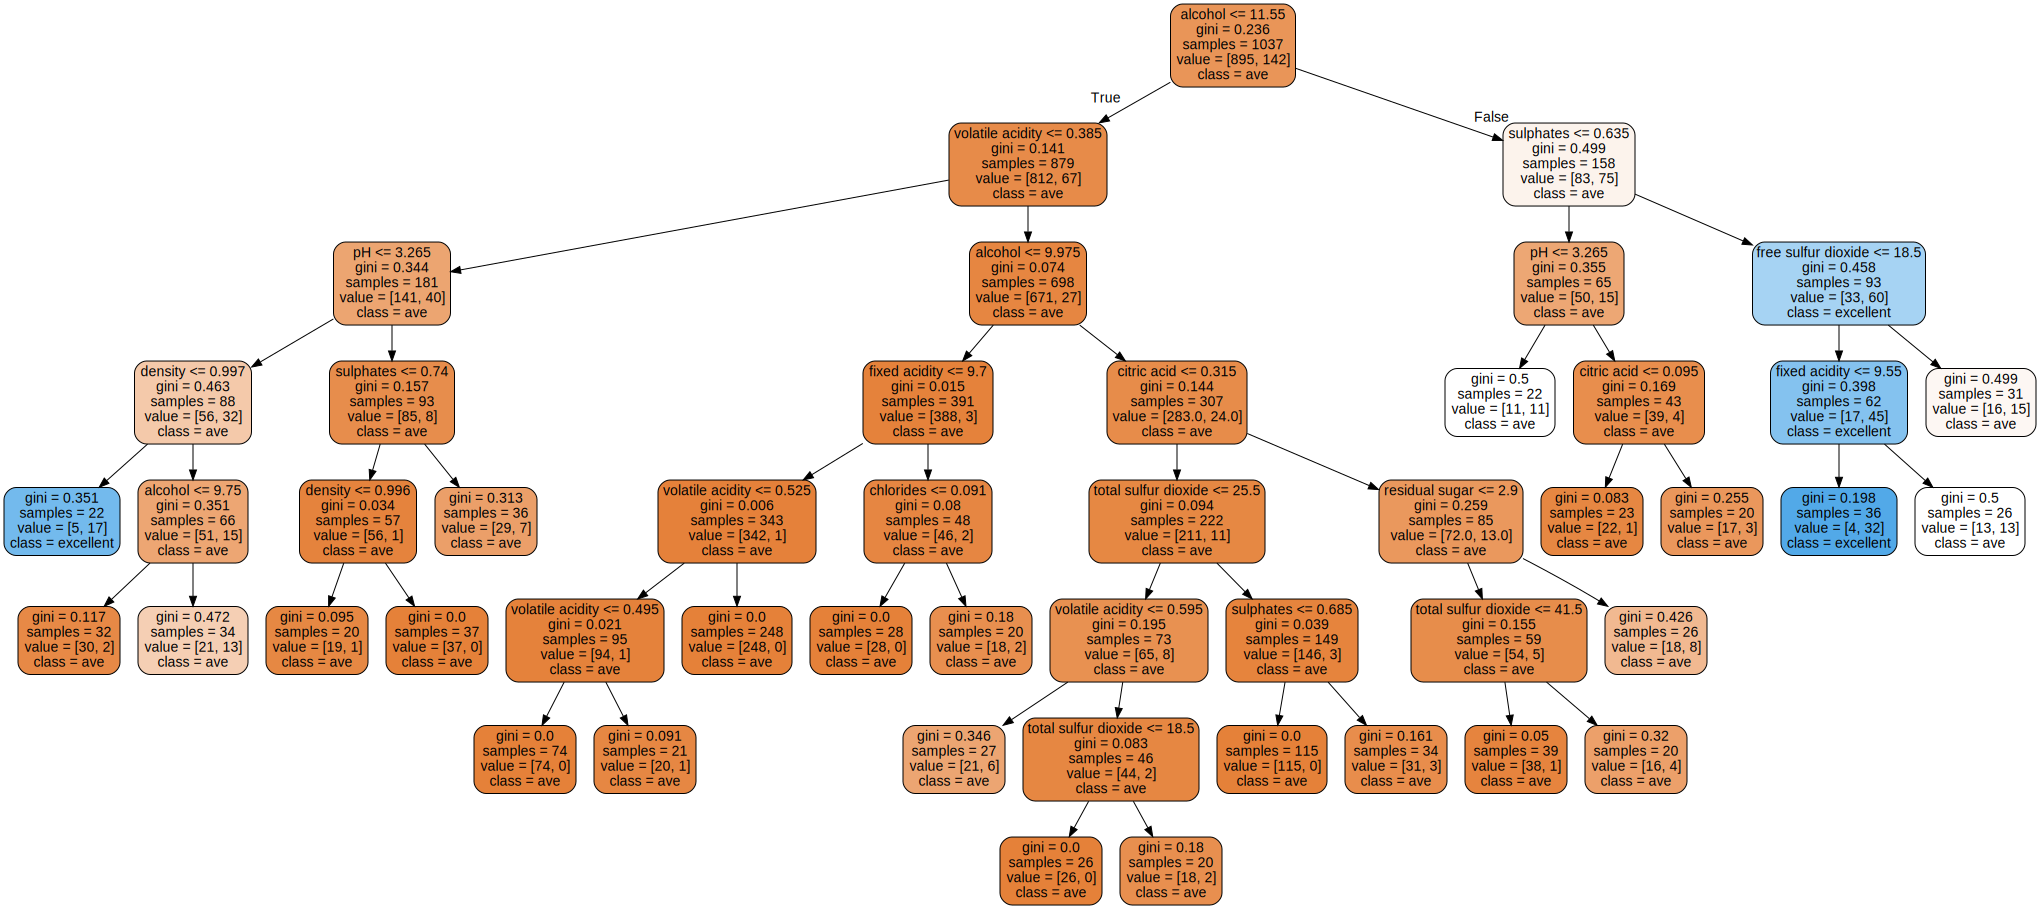

In [68]:
#Plotting the decision tree for the best estimator
# export_graphviz requires a fitted DecisionTreeClassifier, so we extract it from the pipeline
dot_data = export_graphviz(best.named_steps['classifier'], out_file=None,
               feature_names=X.columns,
               filled=True,
               rounded=True,
               class_names=['ave','excellent'])

graph = graphviz.Source(dot_data)
graph


In [69]:
#What about the specific scores (roc_auc, recall, balanced_accuracy)? Let's try and extract them to see what we are working with ...
print(model.cv_results_) #This is a dictionary and in order to extract info we need the keys

{'mean_fit_time': array([0.01719449, 0.01591001, 0.01693432, 0.01645334, 0.01673077]), 'std_fit_time': array([0.00575426, 0.00686973, 0.00649734, 0.00594607, 0.00549619]), 'mean_score_time': array([0.02063899, 0.02140776, 0.02470652, 0.0253001 , 0.02562366]), 'std_score_time': array([0.00756027, 0.00907112, 0.00901019, 0.00895569, 0.01001723]), 'param_classifier__min_samples_leaf': masked_array(data=[5, 10, 15, 20, 25],
             mask=[False, False, False, False, False],
       fill_value=999999), 'params': [{'classifier__min_samples_leaf': 5}, {'classifier__min_samples_leaf': 10}, {'classifier__min_samples_leaf': 15}, {'classifier__min_samples_leaf': 20}, {'classifier__min_samples_leaf': 25}], 'split0_test_roc_auc': array([0.86865079, 0.88214286, 0.85119048, 0.84444444, 0.83492063]), 'split1_test_roc_auc': array([0.81944444, 0.76547619, 0.83134921, 0.8468254 , 0.81150794]), 'split2_test_roc_auc': array([0.8515873 , 0.86825397, 0.90992063, 0.94722222, 0.93928571]), 'split3_test_roc_

In [70]:
#Which one of these do we need?
print(model.cv_results_.keys()) #get mean_test and std_test for all of our scores, and will need our param_max_depth as well

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_classifier__min_samples_leaf', 'params', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'split5_test_roc_auc', 'split6_test_roc_auc', 'split7_test_roc_auc', 'split8_test_roc_auc', 'split9_test_roc_auc', 'split10_test_roc_auc', 'split11_test_roc_auc', 'split12_test_roc_auc', 'split13_test_roc_auc', 'split14_test_roc_auc', 'split15_test_roc_auc', 'split16_test_roc_auc', 'split17_test_roc_auc', 'split18_test_roc_auc', 'split19_test_roc_auc', 'split20_test_roc_auc', 'split21_test_roc_auc', 'split22_test_roc_auc', 'split23_test_roc_auc', 'split24_test_roc_auc', 'split25_test_roc_auc', 'split26_test_roc_auc', 'split27_test_roc_auc', 'split28_test_roc_auc', 'split29_test_roc_auc', 'split30_test_roc_auc', 'split31_test_roc_auc', 'split32_test_roc_auc', 'split33_test_roc_auc', 'split34_test_roc_auc', 'split35_test_roc_auc', 'split36_test_roc

In [71]:
#Let's extract these scores, using our function!

#Scores:
auc     = model.cv_results_['mean_test_roc_auc']
recall  = model.cv_results_['mean_test_recall']
bal_acc = model.cv_results_['mean_test_balanced_accuracy']

SDauc     = model.cv_results_['std_test_roc_auc']
SDrecall  = model.cv_results_['std_test_recall']
SDbal_acc = model.cv_results_['std_test_balanced_accuracy']

#Parameter: note the key is now 'param_classifier__max_depth' because we are using a pipeline
depth = np.unique(model.cv_results_['param_classifier__min_samples_leaf']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc, SDauc, SDrecall, SDbal_acc)),
               columns=['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
print(final_model.to_string(index=False))


 depth      auc   recall  bal_acc    aucSD  recallSD  bal_accSD
     5 0.779160 0.431714 0.679203 0.064071  0.127493   0.064427
    10 0.803182 0.383238 0.663439 0.055329  0.125881   0.060627
    15 0.814888 0.360667 0.655743 0.061090  0.125815   0.061381
    20 0.827205 0.318476 0.636771 0.059084  0.123151   0.059786
    25 0.818776 0.342000 0.645849 0.055391  0.141686   0.065909


In [72]:
#Warning!
#If we used multiple params... you won't be able to get the scores as easily
#Say we wanted to get the scores based on max_depth still, but this time we used the parameter ccp_alpha as well
#Use the np.where function to search for the indices where the other parameter equals their best result, in this say it is .001
#This is an example code to find auc: #model.cv_results_['mean_test_roc_auc'][np.where((model.cv_results_['param_ccp_alpha'] == .001))]
#Essentially takes indices and resulting scores where the best parameters were used

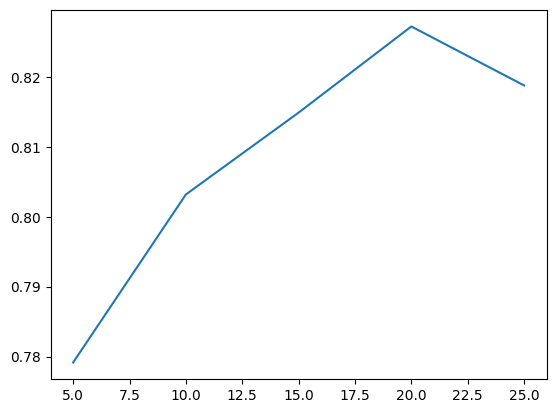

In [73]:
#Check the depth ...
print(plt.plot(final_model.depth,final_model.auc)) #5 does in fact have the highest (best) AUC!

# Variable Importance

Variable importance (also called **feature importance**) answers the question:  
*"How much does each feature contribute to the predictions made by the tree?"*

## How is it calculated?

Scikit-learn computes feature importances using the **mean decrease in impurity (MDI)**, sometimes called
**Gini importance**:

1. Every time a feature is chosen as the splitting variable at a node, the impurity (Gini or entropy)
   of the child nodes is compared with the parent node.
2. The **weighted impurity reduction** at that split is attributed to the feature.
3. These reductions are summed across **all nodes** in the tree where that feature was used.
4. Finally the values are **normalised** so they sum to 1.0.

$$\text{Importance}(f) = \frac{\sum_{t \in \text{nodes splitting on } f} n_t \cdot \Delta I_t}{\sum_{t \in \text{all nodes}} n_t \cdot \Delta I_t}$$

where $n_t$ is the number of samples reaching node $t$ and $\Delta I_t$ is the impurity decrease at that node.

## Interpreting the values

| Value range | Interpretation |
|-------------|----------------|
| Close to **1.0** | Feature is almost solely responsible for all splits |
| **0.0** | Feature was never used in any split |
| All equal | No single feature dominates; tree uses all features equally |

## Caveats

* MDI can be **biased toward high-cardinality features** (features with many unique values appear more important
  than they might truly be).
* It measures importance within *this particular tree*; a different random seed or training set may produce
  different rankings.
* For a more robust measure consider **permutation importance** (`sklearn.inspection.permutation_importance`),
  which directly measures the drop in test-set performance when each feature's values are shuffled.


In [74]:
#Variable importance for the best estimator
# The DecisionTreeClassifier lives inside the pipeline under the 'classifier' step
varimp = pd.DataFrame(
    best.named_steps['classifier'].feature_importances_,
    index=X.columns,
    columns=['importance']
).sort_values('importance', ascending=False)

print(varimp)


                      importance
alcohol                 0.443070
sulphates               0.138937
pH                      0.109726
volatile acidity        0.099866
density                 0.091975
fixed acidity           0.043672
free sulfur dioxide     0.022515
total sulfur dioxide    0.016882
residual sugar          0.016696
citric acid             0.014489
chlorides               0.002171


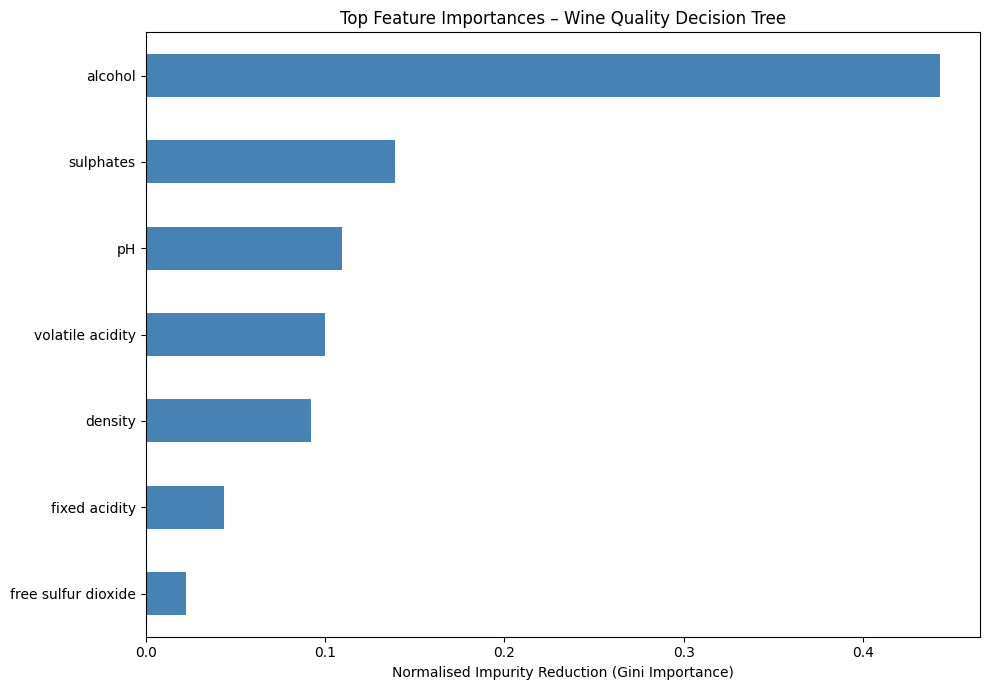


Alcohol content has the largest impact by far!


In [75]:
#Graph variable importance – horizontal bar chart of the top features
fig, ax = plt.subplots(figsize=(10, 7))
varimp.importance.nlargest(7).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Normalised Impurity Reduction (Gini Importance)')
ax.set_title('Top Feature Importances – Wine Quality Decision Tree')
plt.tight_layout()
plt.show()
print('\nAlcohol content has the largest impact by far!')


## Cross-Validation → Validation Set → Test Set: Step-by-Step Evaluation

A rigorous ML workflow separates data into **three** non-overlapping sets:

| Set | Purpose |
|-----|---------|
| **Training set** (`X_train`) | Fit the model; cross-validation folds are drawn from here |
| **Validation / Tuning set** (`X_tune`) | Intermediate evaluation after hyper-parameter selection to detect over-fitting before touching the test set |
| **Test set** (`X_test`) | Final, once-only evaluation to report generalisation performance |

We already have all three sets from the earlier `train_test_split` calls.  
Below we explicitly report performance at each stage so we can spot any train→validation→test degradation.


In [76]:
# ── Stage 1: Cross-validation scores from GridSearchCV (on the training set) ──
print('=== Stage 1: Cross-Validation Scores (training folds) ===')
print(f"  Best max_depth : {model.best_params_['classifier__min_samples_leaf']}")
print(f"  CV AUC         : {model.best_score_:.4f}")

# Cross-validate the best pipeline on the training set for a detailed score breakdown
cv_results = cross_validate(
    best, X_train, y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)
print('\n  Detailed CV score summary (training set):')
for metric in ['roc_auc', 'recall', 'balanced_accuracy']:
    train_scores = cv_results[f'train_{metric}']
    test_scores  = cv_results[f'test_{metric}']
    print(f"    {metric:<20s}  train={train_scores.mean():.4f}±{train_scores.std():.4f}  "
          f"val={test_scores.mean():.4f}±{test_scores.std():.4f}")


=== Stage 1: Cross-Validation Scores (training folds) ===
  Best max_depth : 20
  CV AUC         : 0.8272

  Detailed CV score summary (training set):
    roc_auc               train=0.9338±0.0047  val=0.8272±0.0591
    recall                train=0.4573±0.0725  val=0.3185±0.1232
    balanced_accuracy     train=0.7152±0.0320  val=0.6368±0.0598


=== Stage 2: Validation-Set Evaluation ===
  AUC               : 0.8740
  Recall (TPR)      : 0.3667
  Balanced Accuracy : 0.6703

Validation Confusion Matrix:


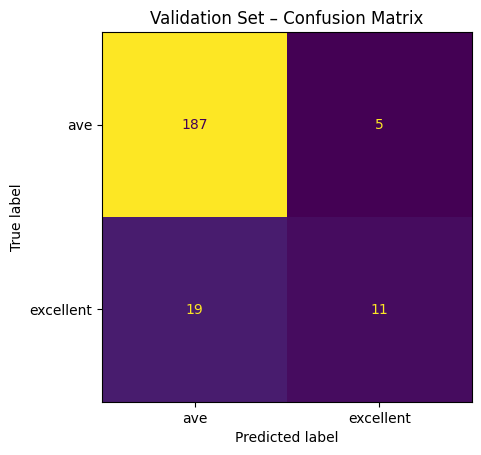

In [77]:
# ── Stage 2: Evaluate the best pipeline on the held-out validation (tuning) set ──
print('=== Stage 2: Validation-Set Evaluation ===')

y_val_pred  = best.predict(X_tune)
y_val_proba = best.predict_proba(X_tune)[:, 1]

val_auc  = metrics.roc_auc_score(y_tune, y_val_proba)
val_rec  = metrics.recall_score(y_tune, y_val_pred)
val_bacc = metrics.balanced_accuracy_score(y_tune, y_val_pred)

print(f'  AUC               : {val_auc:.4f}')
print(f'  Recall (TPR)      : {val_rec:.4f}')
print(f'  Balanced Accuracy : {val_bacc:.4f}')

print('\nValidation Confusion Matrix:')
ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune,
                                      display_labels=['ave','excellent'],
                                      colorbar=False)
plt.title('Validation Set – Confusion Matrix')
plt.show()


=== Stage 3: Test-Set Evaluation (final) ===
  AUC               : 0.8744
  Recall (TPR)      : 0.3548
  Balanced Accuracy : 0.6540
  Accuracy          : 0.8700

Test Confusion Matrix:


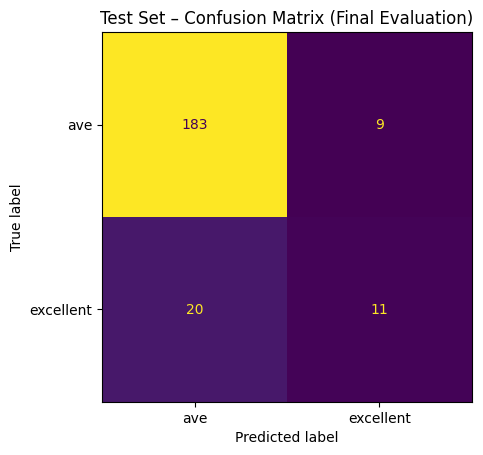


ROC Curve (Test Set):


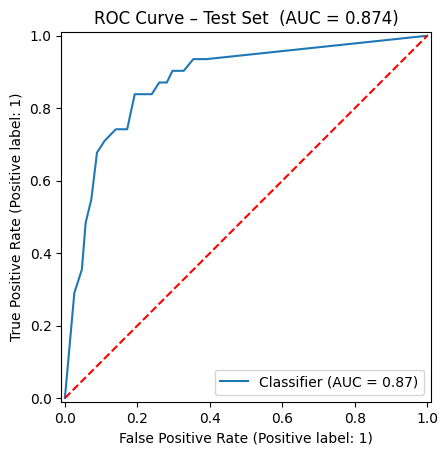

In [78]:
# ── Stage 3: Final evaluation on the held-out test set ──────────────────────
# This should be done ONCE, only after all hyper-parameter choices are finalised.
print('=== Stage 3: Test-Set Evaluation (final) ===')

y_test_pred  = best.predict(X_test)
y_test_proba = best.predict_proba(X_test)[:, 1]

test_auc  = metrics.roc_auc_score(y_test, y_test_proba)
test_rec  = metrics.recall_score(y_test, y_test_pred)
test_bacc = metrics.balanced_accuracy_score(y_test, y_test_pred)
test_acc  = metrics.accuracy_score(y_test, y_test_pred)

print(f'  AUC               : {test_auc:.4f}')
print(f'  Recall (TPR)      : {test_rec:.4f}')
print(f'  Balanced Accuracy : {test_bacc:.4f}')
print(f'  Accuracy          : {test_acc:.4f}')

print('\nTest Confusion Matrix:')
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test,
                                      display_labels=['ave','excellent'],
                                      colorbar=False)
plt.title('Test Set – Confusion Matrix (Final Evaluation)')
plt.show()

print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()


## Let's use the model to predict and the evaluate the performance

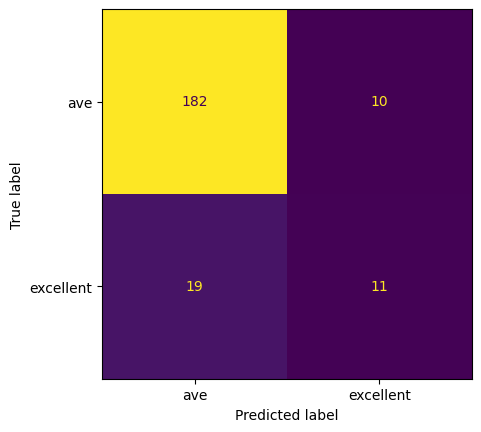

In [32]:
#Confusion Matrix time! Passing our tuning data into our best model, let's see how we do ...
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune, display_labels = ['ave','excellent'], colorbar=False))

## Let's play with the threshold, what do we see

In [ ]:
## Adjust threshold function
def adjust_thres(model,X,y_true, thres):
  #model= best estimator, X= feature vairables, y_true= target variables, thres = threshold
  y_pred = (model.predict_proba(X)[:,1] >= thres).astype(np.int32) #essentially changes the prediction cut off to our desired threshold
  return metrics.ConfusionMatrixDisplay.from_predictions(y_true,y_pred, display_labels = ['ave','excellent'], colorbar=False)

In [ ]:
#Where should we change the threshold to see a difference...
# model.best_estimator_ is the pipeline, which supports predict_proba
print(pd.DataFrame(best.predict_proba(X_tune)[:,1]).plot.density())


In [ ]:
#Let's try .1 as our new threshold ...
print(adjust_thres(best,X_tune, y_tune,.1))

## Accuracy Score

In [ ]:
# The pipeline's score() method runs predict() end-to-end, including all preprocessing steps
print('Test set accuracy:', best.score(X_test, y_test))


NameError: name 'best' is not defined

In [ ]:
print('Validation set accuracy:', best.score(X_tune, y_tune))


## Feature Engineering:

In [ ]:
#What feature should we look at?
print(winequality.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1482.000000       1482.000000  1482.000000     1482.000000   
mean        8.320243          0.528870     0.269744        2.548853   
std         1.718001          0.180651     0.194912        1.431911   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1482.000000          1482.000000           1482.000000  1482.000000   
mean      0.087808            16.018893             46.965587     0.996764   
std       0.048015            10.419929             33.141959     0.001868   
min       0.012000             1.000000         

In [ ]:
# How about total sulfur dioxide ...
print(plt.hist(winequality['total sulfur dioxide'], width=15, bins = 15))

In [ ]:
#Get the five number summary, and some...
print(winequality['total sulfur dioxide'].describe())

In [ ]:
#make a new dataframe so we can preserve our working environment
winequality1 = winequality.copy(deep=True)

In [ ]:
#lump total sulfure dioxide to below and above its median (38)
winequality1['total sulfur dioxide']=pd.cut(winequality1['total sulfur dioxide'],(0,37,300), labels = ("low","high"))

In [ ]:
#NOTE: Previously we manually applied OrdinalEncoder here.
#Now that OrdinalEncoder is part of the Pipeline's preprocessor step, we leave
#'total sulfur dioxide' as the string category ('low'/'high') so the pipeline can
#encode it consistently within each cross-validation fold.
#winequality1[['total sulfur dioxide']] = OrdinalEncoder().fit_transform(winequality1[['total sulfur dioxide']])
print(winequality1['total sulfur dioxide'].value_counts())


In [ ]:
#Separate features and target
X1=winequality1.drop(columns='text_rank')
y1=winequality1.text_rank

In [ ]:
#Data splitting
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, train_size=0.70, stratify= y1, random_state=21)
X_tune1, X_test1, y_tune1, y_test1 = train_test_split(X_test1,y_test1,  train_size = 0.50,stratify= y_test1, random_state=49)

In [ ]:
#Build a feature-engineering pipeline: the OrdinalEncoder for the bucketed column
# is now part of the pipeline, preventing data leakage and keeping the workflow clean.

# Identify the engineered categorical column and the rest (passthrough)
cat_features = ['total sulfur dioxide']
num_features = [c for c in X1.columns if c not in cat_features]

# Preprocessor: encode the categorical column, pass numeric columns unchanged
preprocessor = ColumnTransformer([
    ('encoder',     OrdinalEncoder(),  cat_features),
    ('passthrough', 'passthrough',     num_features)
])

# Full pipeline: preprocessing → classifier
pipe_eng = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=1000))
])

# Hyper-parameter grid for the engineering pipeline
param_eng = {'classifier__max_depth': [1,2,3,4,5,6,7,8,9,10,11]}

search_eng = GridSearchCV(pipe_eng, param_eng, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

#execute search – X_train1 still contains the raw (un-encoded) 'total sulfur dioxide' values
#The pipeline's preprocessor will apply OrdinalEncoder inside each cross-validation fold
model_eng = search_eng.fit(X_train1, y_train1)


In [ ]:
#Take a look at our best estimator for the engineering pipeline
best_eng = model_eng.best_estimator_
print(best_eng)

best_clf_eng = best_eng.named_steps['classifier']
print('\nBest max_depth:', best_clf_eng.max_depth)


In [ ]:
#Check out the mean and standard deviation test scores for the engineering pipeline ...
auc     = model_eng.cv_results_['mean_test_roc_auc']
recall  = model_eng.cv_results_['mean_test_recall']
bal_acc = model_eng.cv_results_['mean_test_balanced_accuracy']

SDauc     = model_eng.cv_results_['std_test_roc_auc']
SDrecall  = model_eng.cv_results_['std_test_recall']
SDbal_acc = model_eng.cv_results_['std_test_balanced_accuracy']

#Parameter: note prefix 'classifier__' because of the pipeline
depth = np.unique(model_eng.cv_results_['param_classifier__max_depth']).data

#Build DataFrame:
final_model_eng = pd.DataFrame(list(zip(depth, auc, recall, bal_acc, SDauc, SDrecall, SDbal_acc)),
               columns=['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
print(final_model_eng.to_string(index=False))


# Compare the confusion matrices from the two models

In [ ]:
#First model
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune,colorbar=False))

In [ ]:
#New engineered model
print(ConfusionMatrixDisplay.from_estimator(best_eng,X_tune1,y_tune1,colorbar=False)) #Better tpr and tnr!

## We can also review the variable importance

In [ ]:
#First model – extract classifier from pipeline
print(pd.DataFrame(best.named_steps['classifier'].feature_importances_,index=X.columns,columns=['importance']).sort_values('importance', ascending=False))


In [ ]:
#Engineered model variable importance – extract classifier from the pipeline
# The ColumnTransformer in the pipeline reorders columns: encoded columns first, then passthrough.
# Use get_feature_names_out() to get the correct ordering of feature names from the preprocessor.
feature_names_eng = (
    best_eng.named_steps['preprocessor'].get_feature_names_out().tolist()
)
# Strip the step prefix added by ColumnTransformer (e.g. 'encoder__x' -> 'total sulfur dioxide')
feature_names_eng = [
    n.split('__', 1)[-1] if '__' in n else n for n in feature_names_eng
]

varimp_eng = pd.DataFrame(
    best_eng.named_steps['classifier'].feature_importances_,
    index=feature_names_eng,
    columns=['importance']
).sort_values('importance', ascending=False)
print(varimp_eng)
#Smaller model so fewer variables are considered important


## Predict with test, how did we do?

In [ ]:
#Original model
print(ConfusionMatrixDisplay.from_estimator(best,X_test,y_test,colorbar=False))

In [ ]:
#New engineered model
print(ConfusionMatrixDisplay.from_estimator(best_eng,X_test1,y_test1,colorbar=False)) #Ultimately, very similar results

## How about accuracy score?

In [ ]:
#Original model
print(best.score(X_test,y_test)) #accuracy

In [ ]:
#Engineered model
print(best_eng.score(X_test1,y_test1)) #Basically the same

## Another example with a binary dataset this time!

In [ ]:
#Load in new dataset
pregnancy = pd.read_csv("https://raw.githubusercontent.com/UVADS/DS-3001/main/data/pregnancy.csv")

In [ ]:
#Let's get familiar with the data
print(pregnancy.info())
print(pregnancy.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Pregnancy Test          2000 non-null   int64
 1   Birth Control           2000 non-null   int64
 2   Feminine Hygiene        2000 non-null   int64
 3   Folic Acid              2000 non-null   int64
 4   Prenatal Vitamins       2000 non-null   int64
 5   Prenatal Yoga           2000 non-null   int64
 6   Body Pillow             2000 non-null   int64
 7   Ginger Ale              2000 non-null   int64
 8   Sea Bands               2000 non-null   int64
 9   Stopped buying ciggies  2000 non-null   int64
 10  Cigarettes              2000 non-null   int64
 11  Smoking Cessation       2000 non-null   int64
 12  Stopped buying wine     2000 non-null   int64
 13  Wine                    2000 non-null   int64
 14  Maternity Clothes       2000 non-null   int64
 15  PREGNANT             

In [ ]:
#We want to build a classifier that can predict whether a shopper is pregnant
#based on the items they buy so we can direct-market to that customer if possible.

print(pregnancy.PREGNANT.sum())
print(len(pregnancy.PREGNANT))

print((1- pregnancy.PREGNANT.sum()/len(pregnancy.PREGNANT)))
#What does .72 represent in this context? Prevalence of not being pregnant

560
2000
0.72


# reformat for exploration purposes

In [ ]:
#Creating a vertical dataframe for the pregnant variable, just stacking the variables on top of each other.
#First get the column names of features then use pd.melt based on the Pregnancy variable
feature_cols = pregnancy.drop(columns='PREGNANT').columns
pregnancy_long = df = pd.melt(pregnancy, id_vars='PREGNANT', value_vars=feature_cols,
             var_name='variable', value_name='value')


print(pregnancy_long.head())

   PREGNANT        variable  value
0         1  Pregnancy Test      1
1         1  Pregnancy Test      1
2         1  Pregnancy Test      1
3         1  Pregnancy Test      0
4         1  Pregnancy Test      0


# See what the base rate likihood of pregnancy looks like for each variable

In [ ]:
# Calculate the probability of being pregnant by predictor variable.
# First let's create a new list to store our probability data
data=[]
#loop through features and retrieve probability of pregnancy for whether it is bought or not bought
#Since the data is binary you can take the average to get the probability.
for col in feature_cols:
    x = pregnancy.groupby([col])['PREGNANT'].mean()
    data.extend([[col,0,x[0]],[col,1,x[1]]])
base_rate = pd.DataFrame(data, columns = ['Var', 'Value','prob_pregnant'])
base_rate['prob_not_pregnant']= 1-base_rate.prob_pregnant
print(base_rate)

                       Var  Value  prob_pregnant  prob_not_pregnant
0           Pregnancy Test      0       0.254441           0.745559
1           Pregnancy Test      1       0.848837           0.151163
2            Birth Control      0       0.327859           0.672141
3            Birth Control      1       0.058989           0.941011
4         Feminine Hygiene      0       0.321212           0.678788
5         Feminine Hygiene      1       0.085714           0.914286
6               Folic Acid      0       0.234792           0.765208
7               Folic Acid      1       0.952381           0.047619
8        Prenatal Vitamins      0       0.236741           0.763259
9        Prenatal Vitamins      1       0.742690           0.257310
10           Prenatal Yoga      0       0.273647           0.726353
11           Prenatal Yoga      1       0.826087           0.173913
12             Body Pillow      0       0.276596           0.723404
13             Body Pillow      1       0.538462

# Build  the model

In [ ]:
#Split between features and target and do a three way split
X_preg=pregnancy.drop(columns='PREGNANT')
y_preg=pregnancy.PREGNANT
X_train_preg, X_test_preg, y_train_preg, y_test_preg = train_test_split(X_preg, y_preg, train_size=0.70, stratify= y_preg, random_state=21)
X_tune_preg, X_test_preg, y_tune_preg, y_test_preg = train_test_split(X_test_preg,y_test_preg,  train_size = 0.50,stratify= y_test_preg, random_state=49)

In [ ]:
#This time we are going to use a different technique to complete our hyper-parameter search

#Build a pipeline for the pregnancy dataset
pipe_preg = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=1000))
])

#prune our model using minimal cost-complexity pruning, this is an algorithm used to prune a tree
#to avoid overfitting. It removes splits that provide low impurity improvement relative to the
#complexity they add. ccp_alpha is the complexity parameter: higher values prune more.
path_preg = pipe_preg.named_steps['classifier'].cost_complexity_pruning_path(
    X_train_preg, y_train_preg
)
ccp_alphas, impurities = path_preg.ccp_alphas, path_preg.impurities


Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

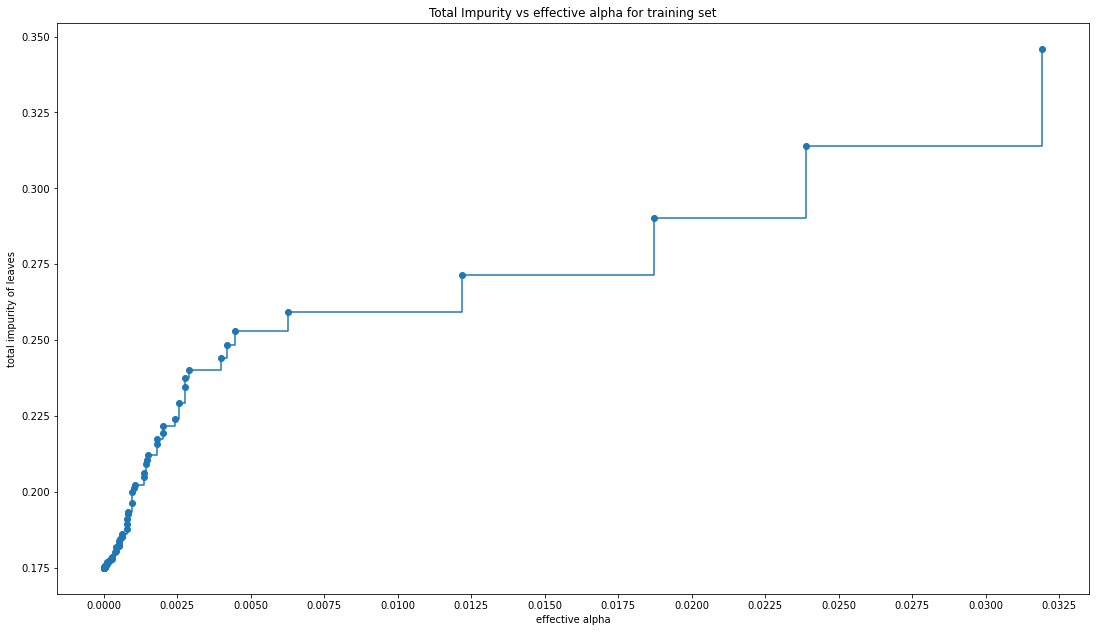

In [ ]:
#Let's do some exploration into what cost complexity alpha gives the best results without overfitting or underfitting ...
fig, ax = plt.subplots()
#In the following plot, the maximum effective alpha value is removed, because it is the trivial tree with only one node
fig.set_size_inches(18.5, 10.5, forward=True)
plt.xticks(ticks=np.arange(0.00,0.06,.0025))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
#As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.

In [ ]:
#run through all of our alphas and create fitted decision tree classifiers for them
clfs = []
for ccp_alpha in ccp_alphas:
    clf_pipe = Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha))
    ])
    clf_pipe.fit(X_train_preg, y_train_preg)
    clfs.append(clf_pipe)



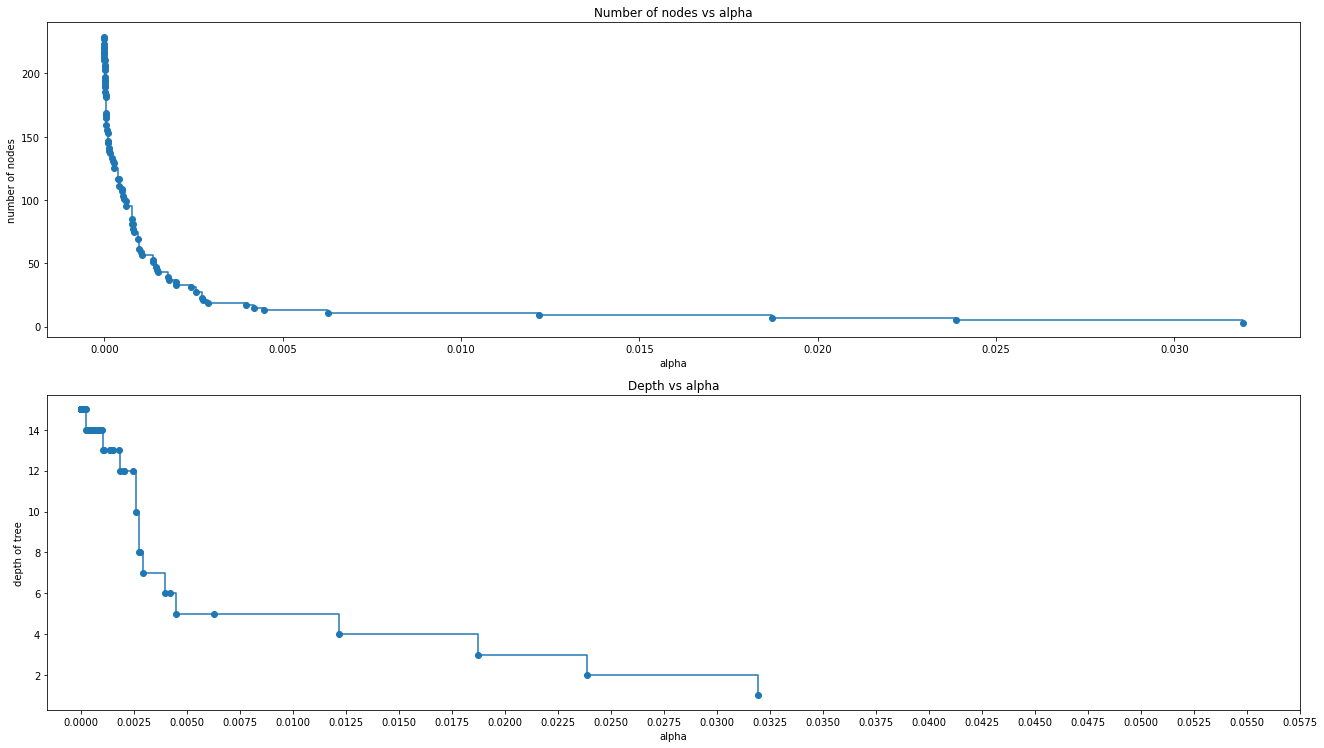

In [ ]:
#we remove the last element in clfs and ccp_alphas (trivial single-node tree)
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Here we show that nodes and depth decrease as alpha increases
node_counts = [clf.named_steps['classifier'].tree_.node_count for clf in clfs]
depth        = [clf.named_steps['classifier'].tree_.max_depth  for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle='steps-post')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('number of nodes')
ax[0].set_title('Number of nodes vs alpha')

ax[1].plot(ccp_alphas, depth, marker='o', drawstyle='steps-post')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('depth of tree')
ax[1].set_title('Depth vs alpha')
fig.tight_layout()
plt.show()


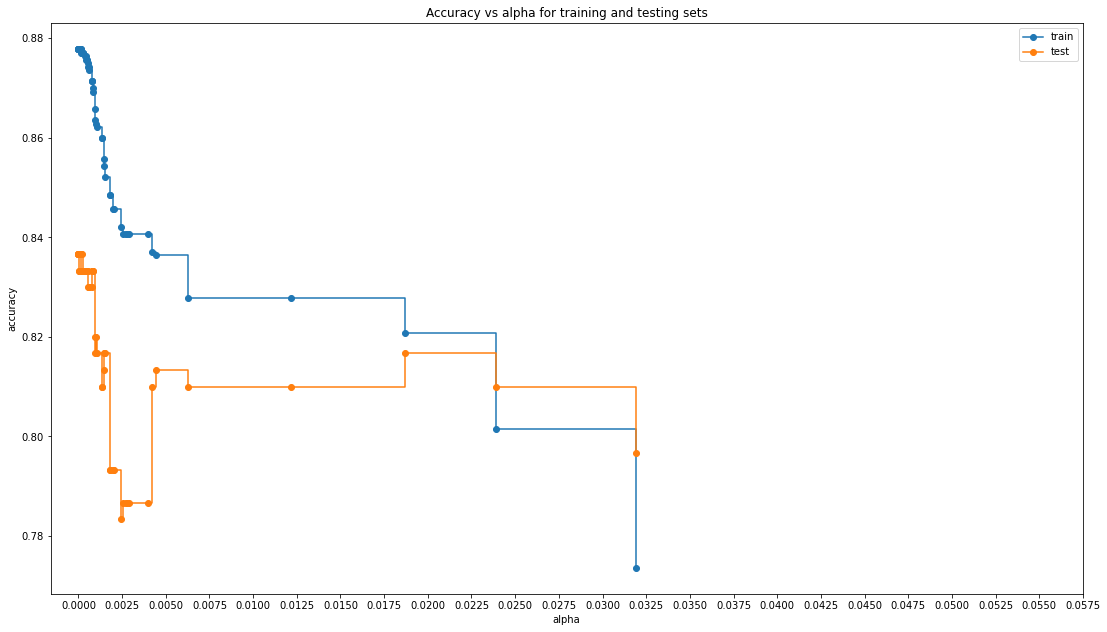

In [ ]:
#When ccp_alpha is set to zero and keeping the other default parameters of DecisionTreeClassifier,
#the tree overfits, leading to a 100% training accuracy and less testing accuracy.
#As alpha increases, more of the tree is pruned, thus creating a decision tree that generalizes better.
#Let's try and find the alpha where we get the highest accuracy for both training and testing data simultaneously
train_scores = [clf.score(X_train_preg, y_train_preg) for clf in clfs]
test_scores = [clf.score(X_tune_preg, y_tune_preg) for clf in clfs]
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.xticks(ticks=np.arange(0.00,0.06,.0025))
fig.set_size_inches(18.5, 10.5, forward=True)
plt.show()
#In this example, setting ccp_alpha=0.001 maximizes the testing accuracy.

In [ ]:
#Let's build a single pipeline with ccp_alpha=0.001 to inspect
tree_pipe = Pipeline([
    ('classifier', DecisionTreeClassifier(ccp_alpha=0.001))
])
tree_pipe.fit(X_train_preg, y_train_preg)

# For convenience also expose the underlying classifier
tree = tree_pipe.named_steps['classifier']


0.8433333333333334

# Variable Importance

In [ ]:
#Variable importance: shows the mean decrease in impurity (Gini) provided by each variable
# A high importance score means removing that variable would significantly increase prediction error.
# Variables with 0 importance were never chosen as a split point by the tree.
varimp_preg = pd.DataFrame(
    tree.feature_importances_,
    index=X_preg.columns,
    columns=['importance']
).sort_values('importance', ascending=False)
print(varimp_preg)

#Visualise the top importances
fig, ax = plt.subplots(figsize=(10, 6))
varimp_preg.importance.nlargest(10).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Normalised Impurity Reduction (Gini Importance)')
ax.set_title('Top Feature Importances – Pregnancy Decision Tree')
plt.tight_layout()
plt.show()


                        importance
Folic Acid                0.282159
Prenatal Vitamins         0.157229
Pregnancy Test            0.117627
Maternity Clothes         0.097533
Stopped buying wine       0.073541
Feminine Hygiene          0.064128
Birth Control             0.063039
Smoking Cessation         0.030172
Ginger Ale                0.029064
Wine                      0.024732
Cigarettes                0.023650
Stopped buying ciggies    0.018642
Sea Bands                 0.013422
Body Pillow               0.005061
Prenatal Yoga             0.000000


# Test the accuracy

In [ ]:
# Evaluate the pipeline on the test set
print('Test accuracy:', tree_pipe.score(X_test_preg, y_test_preg))


0.8433333333333334

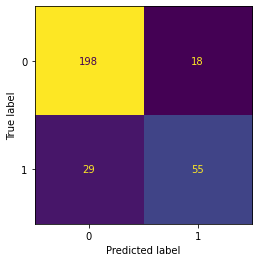

In [ ]:
#Confusion matrix using the full pipeline
ConfusionMatrixDisplay.from_estimator(tree_pipe, X_test_preg, y_test_preg, colorbar=False)
plt.title('Test Set – Pregnancy Decision Tree')
plt.show()


## Hit Rate or True Classification Rate, Detection Rate and ROC

In [ ]:
# The error rate is defined as a classification of 'Pregnant' when
# this is not the case, and vice versa.
pred_preg = tree_pipe.predict(X_test_preg)
tn, fp, fn, tp = metrics.confusion_matrix(y_test_preg, pred_preg).ravel()
print('Sensitivity (Recall/TPR):', tp/(tp+fn))
print('Specificity (TNR)        :', tn/(tn+fp))
print('False Positive Rate      :', fp/(fp+tn))
print('False Negative Rate      :', fn/(fn+tp))


Hit Rate/True Error Rate = 15.666666666666668


In [ ]:
#Detection Rate is the rate at which the algo detects the positive class in proportion to the entire classification A/(A+B+C+D) where A is poss poss
print("Detection Rate = " +str((tp)/len(y_test_preg)*100)) #want this to be higher but there is only so high it can go...

Detection Rate = 18.333333333333332


Text(0.5, 0, 'False Positive Rate')

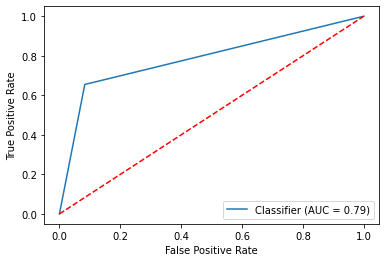

In [ ]:
#Building the evaluation ROC and AUC using the predicted and original target variables
metrics.RocCurveDisplay.from_predictions(y_test_preg, pred_preg)
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve – Pregnancy Decision Tree')
plt.show()


In [ ]:
#We can adjust using a if else statement and the predicted prob, now we have to be 75% sure to classify as pregnant
pred_adjusted = (tree_pipe.predict_proba(X_test_preg)[:,1] >= .75).astype(np.int32)
metrics.RocCurveDisplay.from_predictions(y_test_preg, pred_adjusted)
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve – Adjusted Threshold (0.75)')
plt.show()


# We can also prune the tree to make it less complex

In [ ]:
#Set parameters for our model, this time let's use the complexity parameter
param_preg2 = {'classifier__max_depth': [1,2,3,4,5,6,7],
        #'classifier__splitter': ['best','random'],
        #'classifier__criterion': ['gini','entropy'],
        #'classifier__min_samples_split': [5,10,15,20,25],
        #'classifier__min_samples_leaf': [2,4,6,8,10],
        #'classifier__ccp_alpha': [.001, .01, .1]
           }

# scoring
scoring2 = ['roc_auc', 'recall', 'balanced_accuracy']

# define search using the pipeline
search_preg2 = GridSearchCV(pipe_preg, param_preg2, scoring=scoring2, n_jobs=-1, cv=kf, refit='roc_auc')

#execute search
model_preg2  = search_preg2.fit(X_train_preg, y_train_preg)

#Let's get our results!
best_preg = model_preg2.best_estimator_
print(best_preg)


In [ ]:
print('Max depth after pruning:', tree.tree_.max_depth)


In [ ]:
#let's take a look at the pruned tree – extract classifier from pipeline
dot_data = export_graphviz(best_preg.named_steps['classifier'], out_file=None,
               feature_names=X_preg.columns,
               filled=True,
               rounded=True,
               class_names=['no','yes'])

graph_preg = graphviz.Source(dot_data)
graph_preg


In [ ]:
print('Test accuracy (pruned pregnancy pipeline):', best_preg.score(X_test_preg, y_test_preg))


NameError: name 'best_preg' is not defined